# Recent Holiday Trends and Traveller Behaviour Survey


## The purpose of this survey is to explore recent holiday trends and traveller behaviour. This survey forms part of an academic project for the Statistical Techniques for Data Analytics module.

## Add python libraries to analysis

In [1]:
import pandas as pd
import seaborn as sns
%matplotlib inline  
import matplotlib.pyplot as plt
import numpy as np

# Data Preparation

## Load the Dataset

In [2]:
df_Holidays = pd.read_csv("Holiday_trends_Data_CA1.csv")

## Data Cleaning

### Display first 5 rows, to ensure the data has correctly loaded


In [3]:
df_Holidays.head(5)

,Timestamp,What age range are you in?,Was your holiday,What was the main purpose of your Holiday,How did you book your holiday,How recent was this holiday,How would you describe your holiday type,How many people were in your travel group?,Approximately how much did your accommodation cost per room per night (€)?,How many nights did your holiday last?,"Overall Holiday Cost - Approximate total spend for all travellers (€), including cost of holiday + daily spending.",How satisfied were you with your holiday overall?,Would You Take This Type of Holiday Again?,Did You Travel by Air?,How many holidays have you taken in the last 12 months?
0,25/09/2026 12:25,65+,A Holiday abroad (outside Ireland),"To attend an event (concert, Football match etc)",Independently Booked online,Greater than 3 months ago but within the last ...,A holiday with friends,6,100,3,800,5,Yes,Yes,2
1,25/09/2026 12:25,55-64,A Holiday abroad (outside Ireland),Beach Holiday abroad,A package holiday,In last 3 months,A family holiday,2,150,5,3000,3,Yes,Yes,3
2,25/09/2026 12:27,65+,A Holiday abroad (outside Ireland),Beach Holiday abroad,Independently Booked online,In last 3 months,A family holiday,4,70,28,4800,5,Yes,No,4
3,25/09/2026 12:29,65+,A Holiday abroad (outside Ireland),City Break,Independently Booked online,Greater than 3 months ago but within the last ...,A holiday with friends,6,50,3,500,5,Yes,Yes,2
4,25/09/2026 12:32,25-34,A Holiday abroad (outside Ireland),Other,Independently Booked online,Greater than 3 months ago but within the last ...,A holiday with friends,3,115,6,3000,5,Yes,Yes,3


####  Trim any spaces from the headings

In [4]:
df_Holidays.columns = df_Holidays.columns.str.strip()

## Missing Value Analysis

In [5]:
df_Holidays.isnull().sum()

Timestamp                                                                                                              0
What age range are you in?                                                                                             0
Was your holiday                                                                                                       0
What was the main purpose of your Holiday                                                                              0
How did you book your holiday                                                                                          0
How recent was this holiday                                                                                            0
How would you describe your holiday type                                                                               0
How many people were in your travel group?                                                                             0
Approximately how much did your 

### No missing values were identified in the dataset. Therefore no records required removal

In [6]:
df_Holidays.shape

(57, 15)

In [7]:
df_Holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 15 columns):
 #   Column                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                               --------------  ----- 
 0   Timestamp                                                                                                            57 non-null     object
 1   What age range are you in?                                                                                           57 non-null     object
 2   Was your holiday                                                                                                     57 non-null     object
 3   What was the main purpose of your Holiday                                                                            57 non-null     object
 4   How did you book your 

# Rename columns to make it more readable 

In [8]:
df_Holidays = df_Holidays.rename(columns={
    "Timestamp": "Timestamp",
    "What age range are you in?": "Age_Range",
    "Was your holiday": "Holiday_Location",
    "What was the main purpose of your Holiday": "Holiday_Purpose",
    "How did you book your holiday": "Booking_Method",
    "How recent was this holiday": "Holiday_Recency",
    "How would you describe your holiday type": "Holiday_Type",
    "How many people were in your travel group?": "Group_Size",
    "Approximately how much did your accommodation cost per room per night (€)?": "Accommodation_Cost",
    "How many nights did your holiday last?": "Holiday_Length",
    "Overall Holiday Cost - Approximate total spend for all travellers (€), including  cost of holiday + daily spending.": "Total_Cost",
    "How satisfied were you with your holiday overall?": "Satisfaction",
    "Would You Take This Type of Holiday Again?": "Holiday_Again",
    "Did You Travel by Air?": "Travel_By_Air",
    "How many holidays have you taken in the last 12 months?": "Holidays_Last_12_Months"
    } 
    )

In [9]:
df_Holidays.head(5)

,Timestamp,Age_Range,Holiday_Location,Holiday_Purpose,Booking_Method,Holiday_Recency,Holiday_Type,Group_Size,Accommodation_Cost,Holiday_Length,Total_Cost,Satisfaction,Holiday_Again,Travel_By_Air,Holidays_Last_12_Months
0,25/09/2026 12:25,65+,A Holiday abroad (outside Ireland),"To attend an event (concert, Football match etc)",Independently Booked online,Greater than 3 months ago but within the last ...,A holiday with friends,6,100,3,800,5,Yes,Yes,2
1,25/09/2026 12:25,55-64,A Holiday abroad (outside Ireland),Beach Holiday abroad,A package holiday,In last 3 months,A family holiday,2,150,5,3000,3,Yes,Yes,3
2,25/09/2026 12:27,65+,A Holiday abroad (outside Ireland),Beach Holiday abroad,Independently Booked online,In last 3 months,A family holiday,4,70,28,4800,5,Yes,No,4
3,25/09/2026 12:29,65+,A Holiday abroad (outside Ireland),City Break,Independently Booked online,Greater than 3 months ago but within the last ...,A holiday with friends,6,50,3,500,5,Yes,Yes,2
4,25/09/2026 12:32,25-34,A Holiday abroad (outside Ireland),Other,Independently Booked online,Greater than 3 months ago but within the last ...,A holiday with friends,3,115,6,3000,5,Yes,Yes,3


# Descriptive Statistics

In [10]:
df_Holidays.describe().T

,count,mean,std,min,25%,50%,75%,max
Group_Size,57.0,3.368421,1.867309,1.0,2.0,3.0,4.0,10.0
Accommodation_Cost,57.0,215.228070,531.759781,10.0,80.0,115.0,150.0,4000.0
Holiday_Length,57.0,7.298246,5.418108,1.0,4.0,6.0,7.0,28.0
Total_Cost,57.0,2322.807018,1706.475853,200.0,800.0,2000.0,3000.0,6000.0
Satisfaction,57.0,4.385965,0.700877,3.0,4.0,5.0,5.0,5.0
Holidays_Last_12_Months,57.0,2.754386,2.347344,1.0,2.0,2.0,3.0,18.0


## Skewness Analysis

In [11]:
df_Holidays.skew(numeric_only=True)

Group_Size                 1.467591
Accommodation_Cost         6.730616
Holiday_Length             2.499587
Total_Cost                 0.738628
Satisfaction              -0.705749
Holidays_Last_12_Months    5.036882
dtype: float64

### Accomodation Costs shows a positive skewness (6.33), indicating the presence of extreme observations. In Descriptive Statistics, the average accomodation cost is €221.10, the maximum recorded value is €4,000, suggesting a small number of very expensive holidays are influencing the overall distribution

### Holiday Length also demonstrates a positive skewness of 2.47.  While most holidays show an average of 7.5 days, the maximum holiday length of 28 days was recorded, again this outlier is influencing the overall distribution

### The Satisfaction skewness of (-0.74) indicates that responses are clustered towards the higher end of the rating scale.  This is suggesting that people were generally satisfied with their holiday experience

## Median Analysis

In [12]:
df_Holidays.median(numeric_only=True)

Group_Size                    3.0
Accommodation_Cost          115.0
Holiday_Length                6.0
Total_Cost                 2000.0
Satisfaction                  5.0
Holidays_Last_12_Months       2.0
dtype: float64

### See above median values.  Accomodation costs has a median of €112.50, however the mean is €221.10.  This further demonstrates the impact of extreme values on the distribution

### Show counts of dataset for Age Range, Holiday Purpose and Booking Method

In [13]:
df_Holidays['Age_Range'].value_counts()

Age_Range
35-44    17
25-34    14
45-54    12
55-64     9
65+       5
Name: count, dtype: int64

### The largest responsent group was in the 25-34 range (12).  This was closely followed by the 35-44 and 45-54 age groups. The survey seems to have achieved a representation across most age categories, although fewer replies came from the over 65 age range

In [14]:
df_Holidays['Holiday_Purpose'].value_counts()

Holiday_Purpose
Beach Holiday abroad                                28
City Break                                           9
To visit family / Friends                            9
Other                                                7
To attend an event (concert, Football match etc)     4
Name: count, dtype: int64

### Beach holidays abroad were the most popular holiday type.  This is not surprising as the survey took place immediately after the summer holiday season.  However holidays to attend an event were the least common with 4 responses, again not surprising given the date of the survey

### Show Booking methods as a Percentage

In [15]:
df_Holidays['Booking_Method'].value_counts(normalize=True) * 100

Booking_Method
Independently Booked online    75.438596
A package holiday              24.561404
Name: proportion, dtype: float64

###  This insight shows a preference for booking holidays independently with 75% booking online as opposed to a package option.

## Run a pivot table to show Booking Methods broken down by Age Range

In [16]:
# create a pivot table
pivot_bookings = pd.pivot_table (
    df_Holidays,
    values="Group_Size",
    index="Booking_Method",
    columns="Age_Range",
    aggfunc="count",
    margins=True,
    margins_name="Total"
)
pivot_bookings

Age_Range,25-34,35-44,45-54,55-64,65+,Total
Booking_Method,,,,,,
A package holiday,1,4,4,4,1,14
Independently Booked online,13,13,8,5,4,43
Total,14,17,12,9,5,57


## Independent online booking was the preferred booking method across all age groups. The highest level of independent booking was observed in the 25-34 age category. While package holidays became relatively more common amongst respondents aged 45-64, independently booking online remained the dominant method across every age group surveyed.

## Show the Booking Methods Pivot table as a bar chart

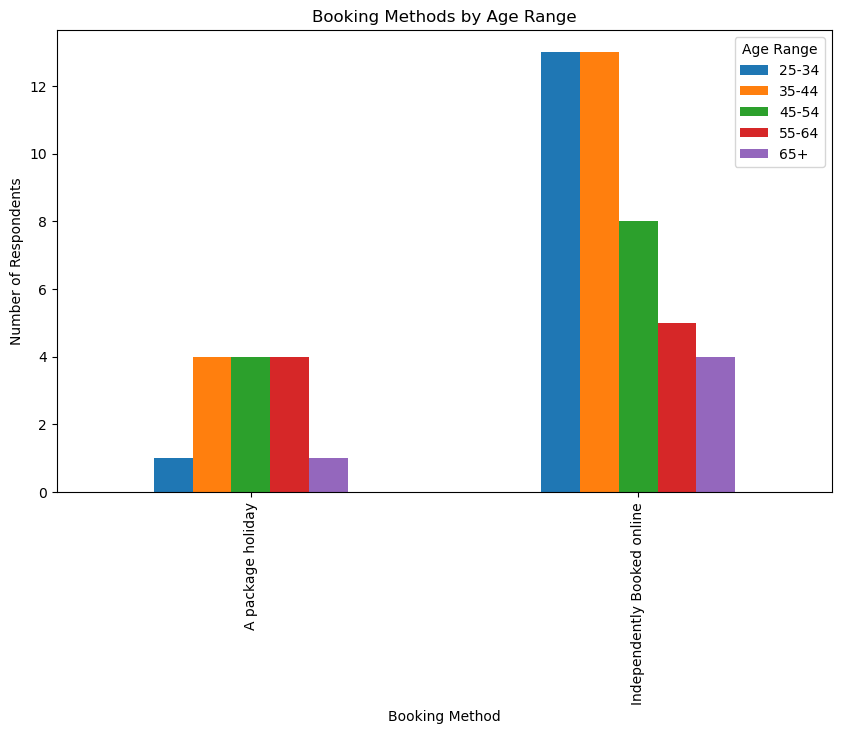

In [17]:
pivot_chart = pivot_bookings.drop(
    index="Total",
    errors="ignore").drop(
    columns="Total",
    errors="ignore")

pivot_chart.plot(
    kind="bar",
    figsize=(10,6))

plt.title("Booking Methods by Age Range")
plt.xlabel("Booking Method")
plt.ylabel("Number of Respondents")
plt.legend(title="Age Range")

plt.show()

## Analysis of Categorical Variables

In [18]:
df_age = df_Holidays['Age_Range'].value_counts()
df_age

Age_Range
35-44    17
25-34    14
45-54    12
55-64     9
65+       5
Name: count, dtype: int64

### Reindex the data to show in age range order

In [19]:
df_age = df_age.reindex( 
    ["25-34", "35-44", "45-54", "55-64", "65+"]
)

## Show Age Range Distribution in a Bar Chart

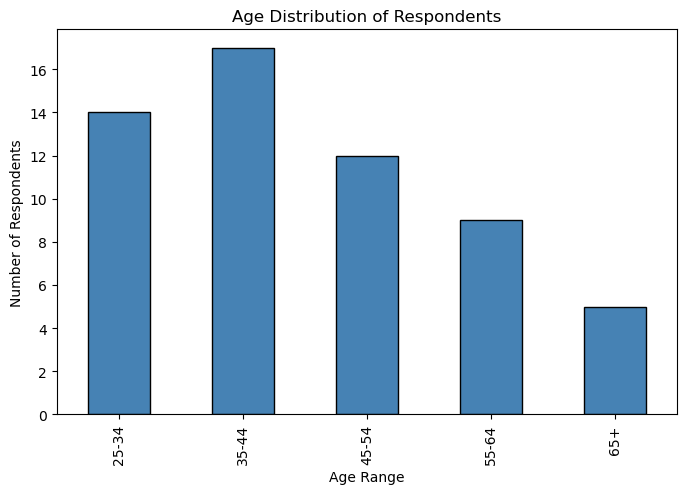

In [20]:
plt.figure(figsize=(8,5) )

df_age.plot.bar(
    color="steelblue",
    edgecolor="black")

plt.title("Age Distribution of Respondents")
plt.xlabel("Age Range")
plt.ylabel("Number of Respondents")

plt.show()



### The age distribution chart shows that respondents were reasonably evenly distributed across the younger and middle-age categories. The 25–34 and 35–44 age groups represented the largest proportion of respondents, while the 65+ category contained the fewest responses.

## Cost Per Night Analysis

### Create a new Data Frame called GroupSize.  Take columns, Group_Size, Holiday_Length, Total_Cost & Satisfaction.  

### A new derived variable, Cost_Per_Night, was created by dividing Total_Cost by Holiday_Length. This gives a new metric for exploratory analysis, allowing holiday spending to be standarsised across all durations

In [21]:
df_Daily_Cost = df_Holidays[
    ["Age_Range","Group_Size", "Holiday_Length", "Total_Cost", "Satisfaction"] 
    ].copy()


In [22]:
df_Daily_Cost.head(3)

,Age_Range,Group_Size,Holiday_Length,Total_Cost,Satisfaction
0,65+,6,3,800,5
1,55-64,2,5,3000,3
2,65+,4,28,4800,5


In [23]:
df_Daily_Cost["Cost_Per_Night"] = (
    df_Daily_Cost["Total_Cost"] / 
    df_Daily_Cost["Holiday_Length"] 
)
df_Daily_Cost.head(3)

,Age_Range,Group_Size,Holiday_Length,Total_Cost,Satisfaction,Cost_Per_Night
0,65+,6,3,800,5,266.666667
1,55-64,2,5,3000,3,600.000000
2,65+,4,28,4800,5,171.428571


In [24]:
df_Daily_Cost.describe().T

,count,mean,std,min,25%,50%,75%,max
Group_Size,57.0,3.368421,1.867309,1.000000,2.0,3.000000,4.000000,10.0
Holiday_Length,57.0,7.298246,5.418108,1.000000,4.0,6.000000,7.000000,28.0
Total_Cost,57.0,2322.807018,1706.475853,200.000000,800.0,2000.000000,3000.000000,6000.0
Satisfaction,57.0,4.385965,0.700877,3.000000,4.0,5.000000,5.000000,5.0
Cost_Per_Night,57.0,362.169345,276.496126,28.571429,200.0,285.714286,454.545455,1250.0


### Create a Pivot Table on the mean off the cost per night and compare with age range.  Plot the results on a Bar chart

In [25]:
pivot_Group = pd.pivot_table(
    df_Daily_Cost,
    values= "Cost_Per_Night",
    index="Age_Range",
    aggfunc="mean"
)

pivot_Group

,Cost_Per_Night
Age_Range,
25-34,292.329932
35-44,369.997564
45-54,451.948052
55-64,405.246914
65+,238.095238


<Figure size 800x500 with 0 Axes>

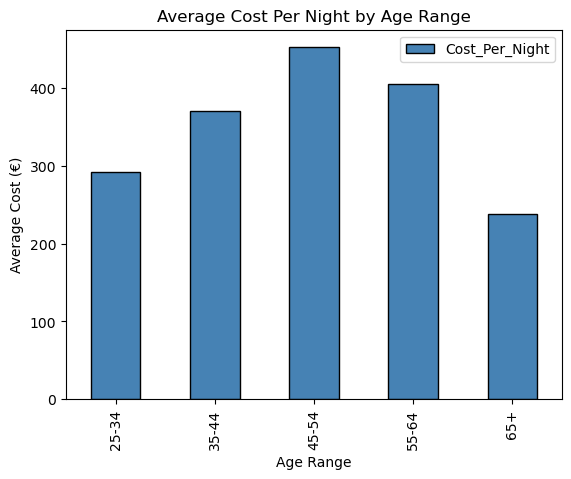

In [26]:
plt.figure(figsize=(8,5) )

pivot_Group.plot.bar(
    color="steelblue",
    edgecolor="black")

plt.title("Average Cost Per Night by Age Range")
plt.xlabel("Age Range")
plt.ylabel("Average Cost (€)")


plt.show()

#### The chart above shows that respondents aged 45-54 recorded the highest average cost per night (€451.94).
#### This was followed by respondents aged 55-64 (€405.25) and 35-44(€369.99).
#### Respondents aged 65+ recorded the lowest cost per night (€238.09).
#### The results suggest that middle aged respondents tend to spend more per night on the overall holiday related expenditure, than their younger or older respondents.
#### However caution is needed when interpreting the results due to the smaller sample size in the 65+ category

## Distribution of Cost Per Night using Seaborn Library

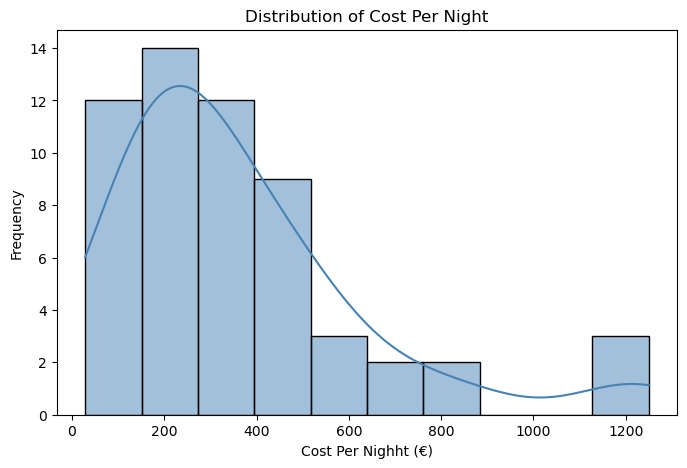

In [29]:
plt.figure(figsize=(8,5) )

sns.histplot(
    data=df_Daily_Cost,
    x="Cost_Per_Night",
    bins=10,
    kde=True,
    color="Steelblue"
)

plt.title("Distribution of Cost Per Night")
plt.xlabel("Cost Per Nighht (€)")
plt.ylabel("Frequency")


plt.show()



####  The histogram of Cost_Per_Night demonstrates a positive skewed distribution.
####  Most respondents recorded a cost per night below €500, whilst a smaller number of respondents reported a significantly higher spending.
####  The presence of these higher vlaues creates a longer tail on the right hand side of the distribution, indicating potential outliers.